In [3]:
import pandas as pd

# Load the CSV file into a DataFrame, specifying the semicolon separator
df = pd.read_csv('/content/base_consolidada_corregida.csv', sep=';')

# Display the first 5 rows of the DataFrame
display(df.head())

,id_usuario,sexo,edad_referencia,total_admisiones,EPS,total_diagnosticos_icd,total_procedimientos_ Quirurgicos,total_estancias_uci,detalle_estancias_uci_es,ibm
0,10000032,Femenino,52,4,Emssanar,39,3,1,4,24
1,10001217,Femenino,55,2,Sanitas,17,4,2,11,32
2,10001725,Femenino,46,1,Asmet,18,3,1,13,22
3,10002428,Femenino,80,7,Nueva Eps,114,17,4,49,19
4,10002495,Masculino,81,1,Nueva Eps,26,7,1,50,35


### 1. Información General del DataFrame

In [4]:
# Muestra información concisa del DataFrame, incluyendo tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   id_usuario                         100 non-null    int64 
 1   sexo                               100 non-null    object
 2   edad_referencia                    100 non-null    int64 
 3   total_admisiones                   100 non-null    int64 
 4   EPS                                100 non-null    object
 5   total_diagnosticos_icd             100 non-null    int64 
 6   total_procedimientos_ Quirurgicos  100 non-null    int64 
 7   total_estancias_uci                100 non-null    int64 
 8   detalle_estancias_uci_es           100 non-null    int64 
 9   ibm                                100 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 7.9+ KB


### 2. Estadísticas Descriptivas

In [5]:
# Muestra estadísticas descriptivas para columnas numéricas
display(df.describe())

,id_usuario,edad_referencia,total_admisiones,total_diagnosticos_icd,total_procedimientos_ Quirurgicos,total_estancias_uci,detalle_estancias_uci_es,ibm
count,1.000000e+02,100.00000,100.0000,100.000000,100.000000,100.000000,100.000000,100.00000
mean,1.001878e+07,61.75000,2.7500,45.060000,7.220000,1.400000,25.760000,26.92000
std,1.115115e+04,16.16979,3.1794,63.597983,7.979241,0.791368,22.721467,4.89832
min,1.000003e+07,21.00000,1.0000,3.000000,0.000000,1.000000,0.000000,18.00000
25%,1.000889e+07,51.75000,1.0000,11.000000,2.000000,1.000000,11.000000,23.00000
50%,1.001909e+07,63.00000,1.0000,22.000000,4.000000,1.000000,18.000000,27.00000
75%,1.002550e+07,72.00000,3.0000,48.250000,10.000000,2.000000,36.250000,31.00000
max,1.004002e+07,91.00000,20.0000,447.000000,34.000000,5.000000,93.000000,35.00000


### 3. Conteo de Valores Nulos

In [6]:
# Muestra el número de valores nulos por columna
display(df.isnull().sum())

,0
id_usuario,0
sexo,0
edad_referencia,0
total_admisiones,0
EPS,0
total_diagnosticos_icd,0
total_procedimientos_ Quirurgicos,0
total_estancias_uci,0
detalle_estancias_uci_es,0
ibm,0


### 4. Análisis de Variables Categóricas

,count
sexo,
Masculino,57
Femenino,43


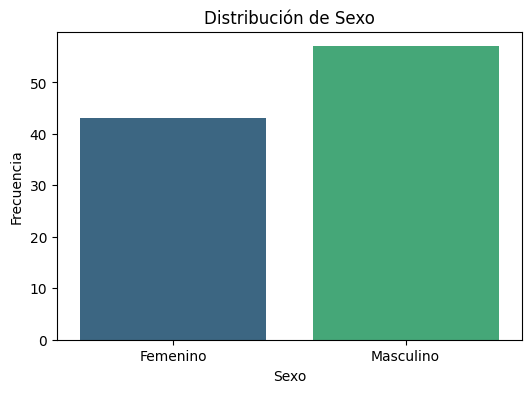

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Conteo de valores únicos para la columna 'sexo'
display(df['sexo'].value_counts())

# Visualización de la distribución de 'sexo'
plt.figure(figsize=(6, 4))
sns.countplot(x='sexo', data=df, palette='viridis', hue='sexo', legend=False)
plt.title('Distribución de Sexo')
plt.xlabel('Sexo')
plt.ylabel('Frecuencia')
plt.show()

,count
EPS,
Emssanar,27
Nueva Eps,26
Asmet,24
Sanitas,23


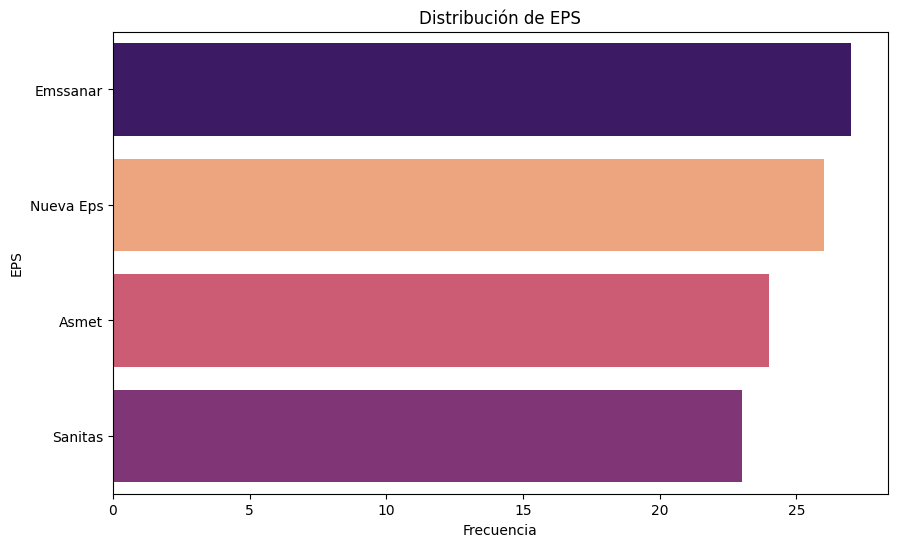

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Conteo de valores únicos para la columna 'EPS'
display(df['EPS'].value_counts())

# Visualización de la distribución de 'EPS'
plt.figure(figsize=(10, 6))
sns.countplot(y='EPS', data=df, order=df['EPS'].value_counts().index, palette='magma', hue='EPS', legend=False)
plt.title('Distribución de EPS')
plt.xlabel('Frecuencia')
plt.ylabel('EPS')
plt.show()

### 5. Análisis de Variables Numéricas

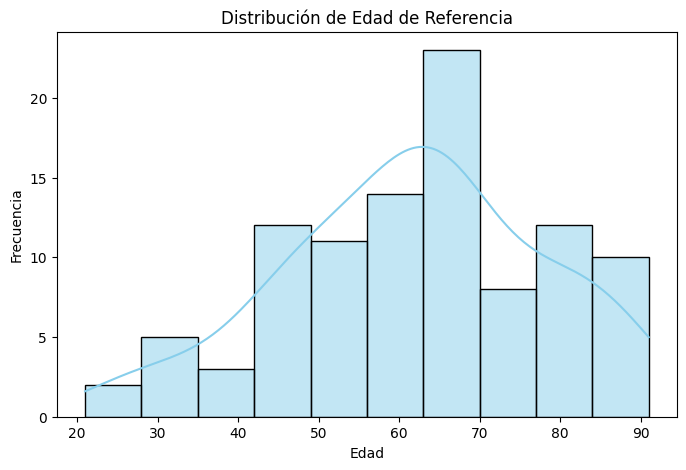

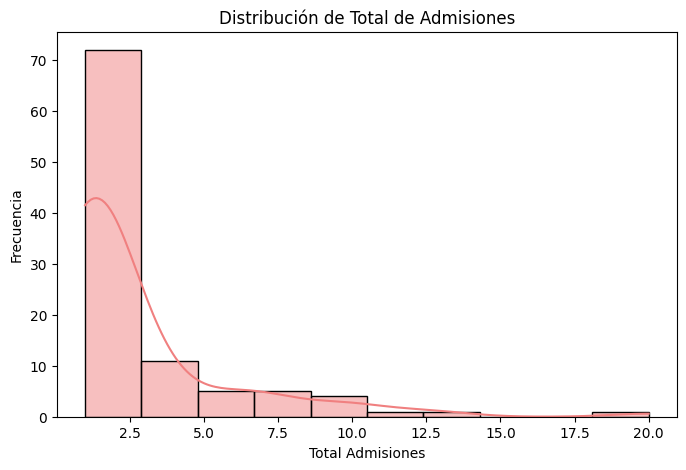

In [9]:
# Histograma para 'edad_referencia'
plt.figure(figsize=(8, 5))
sns.histplot(df['edad_referencia'], bins=10, kde=True, color='skyblue')
plt.title('Distribución de Edad de Referencia')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

# Histograma para 'total_admisiones'
plt.figure(figsize=(8, 5))
sns.histplot(df['total_admisiones'], bins=10, kde=True, color='lightcoral')
plt.title('Distribución de Total de Admisiones')
plt.xlabel('Total Admisiones')
plt.ylabel('Frecuencia')
plt.show()

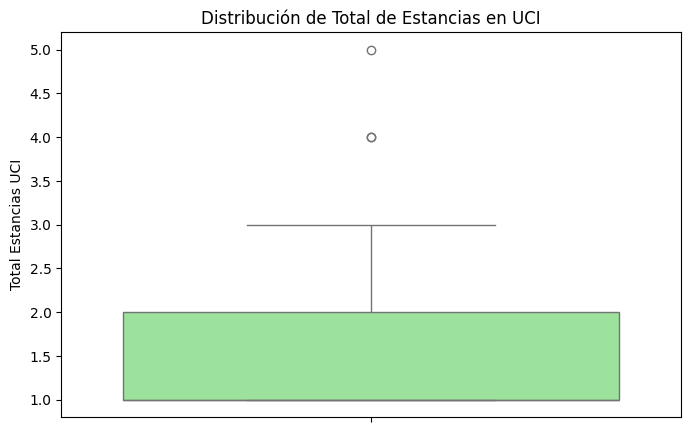

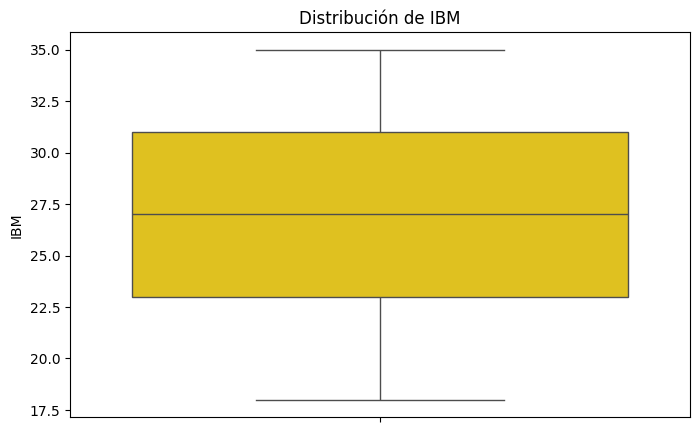

In [10]:
# Boxplot para 'total_estancias_uci'
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['total_estancias_uci'], color='lightgreen')
plt.title('Distribución de Total de Estancias en UCI')
plt.ylabel('Total Estancias UCI')
plt.show()

# Boxplot para 'ibm'
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['ibm'], color='gold')
plt.title('Distribución de IBM')
plt.ylabel('IBM')
plt.show()

### 6. Separación de Variables para Clustering

In [14]:
# Identificar columnas numéricas y categóricas
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Crear DataFrames separados
df_numerical = df[numerical_cols].copy()
df_categorical = df[categorical_cols].copy()

print("Columnas Numéricas:")
display(df_numerical.head())

print("\nColumnas Categóricas:")
display(df_categorical.head())

Columnas Numéricas:


,id_usuario,edad_referencia,total_admisiones,total_diagnosticos_icd,total_procedimientos_ Quirurgicos,total_estancias_uci,detalle_estancias_uci_es,ibm
0,10000032,52,4,39,3,1,4,24
1,10001217,55,2,17,4,2,11,32
2,10001725,46,1,18,3,1,13,22
3,10002428,80,7,114,17,4,49,19
4,10002495,81,1,26,7,1,50,35



Columnas Categóricas:


,sexo,EPS
0,Femenino,Emssanar
1,Femenino,Sanitas
2,Femenino,Asmet
3,Femenino,Nueva Eps
4,Masculino,Nueva Eps


Ahora que hemos separado las variables, podemos trabajar con `df_numerical` directamente para algoritmos de clustering que solo aceptan datos numéricos.

Si deseas incluir las variables categóricas (`sexo`, `EPS`) en el modelo de clustering, deberás convertirlas a un formato numérico. La técnica más común para esto es la **codificación One-Hot (One-Hot Encoding)**.

Con One-Hot Encoding, cada categoría única en una columna se convierte en una nueva columna binaria (0 o 1). Por ejemplo, la columna 'sexo' se podría convertir en 'sexo_Femenino' y 'sexo_Masculino'. Esto evita que el algoritmo asuma una relación ordinal (de orden) entre las categorías que no existe.

### 7. Normalización de Variables Numéricas

Antes de aplicar algoritmos de clustering, es crucial normalizar las variables numéricas. Esto se hace para asegurar que todas las características contribuyan de manera equitativa a la medida de distancia (por ejemplo, distancia euclidiana) utilizada por el algoritmo de clustering. Si las variables no se normalizan, aquellas con rangos de valores más grandes podrían dominar los resultados del clustering.

Utilizaremos la técnica de **Min-Max Scaling** para escalar las variables numéricas a un rango entre 0 y 1.

In [15]:
from sklearn.preprocessing import MinMaxScaler

# Inicializar el MinMaxScaler
scaler = MinMaxScaler()

# Aplicar Min-Max Scaling a las columnas numéricas
df_numerical_scaled = pd.DataFrame(scaler.fit_transform(df_numerical), columns=df_numerical.columns)

print("Variables Numéricas Normalizadas (primeras 5 filas):")
display(df_numerical_scaled.head())

Variables Numéricas Normalizadas (primeras 5 filas):


,id_usuario,edad_referencia,total_admisiones,total_diagnosticos_icd,total_procedimientos_ Quirurgicos,total_estancias_uci,detalle_estancias_uci_es,ibm
0,0.000000,0.442857,0.157895,0.081081,0.088235,0.00,0.043011,0.352941
1,0.029630,0.485714,0.052632,0.031532,0.117647,0.25,0.118280,0.823529
2,0.042332,0.357143,0.000000,0.033784,0.088235,0.00,0.139785,0.235294
3,0.059910,0.842857,0.315789,0.250000,0.500000,0.75,0.526882,0.058824
4,0.061586,0.857143,0.000000,0.051802,0.205882,0.00,0.537634,1.000000


### 8. Aplicación del Algoritmo K-Means

Para determinar el número óptimo de clusters (k) en K-Means, una técnica comúnmente utilizada es el **Método del Codo (Elbow Method)**. Este método consiste en calcular la Suma de los Cuadrados Dentro del Cluster (WCSS por sus siglas en inglés) para diferentes valores de 'k' y luego graficar estos valores. El 'codo' en la gráfica, donde la disminución de WCSS comienza a ser menos pronunciada, sugiere el número apropiado de clusters.

Vamos a calcular el WCSS para un rango de 'k' y luego visualizarlo.

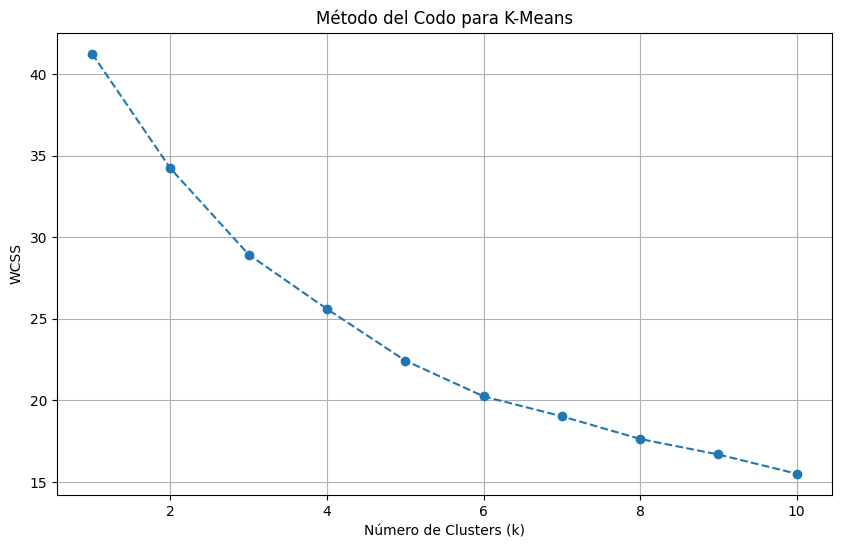

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Probar diferentes números de clusters de 1 a 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_numerical_scaled)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

### 9. Entrenamiento del Modelo K-Means y Asignación de Clusters

Con base en el análisis del Método del Codo, seleccionaremos un número óptimo de clusters (por ejemplo, k=3). Ahora entrenaremos el modelo K-Means con este valor y asignaremos las etiquetas de cluster a cada registro en nuestro DataFrame.

In [17]:
# Elegir el número óptimo de clusters (k) basándose en el gráfico del codo
k = 3 # Puedes ajustar este valor según tu análisis del gráfico

# Entrenar el modelo K-Means con el k seleccionado
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)

# Asignar los clusters a los datos escalados
clusters = kmeans.fit_predict(df_numerical_scaled)

# Añadir las etiquetas de cluster al DataFrame original y al DataFrame escalado
df['cluster'] = clusters
df_numerical_scaled['cluster'] = clusters

print(f"Modelo K-Means entrenado con {k} clusters.")
print("Primeros 5 registros del DataFrame con las etiquetas de cluster:")
display(df.head())

Modelo K-Means entrenado con 3 clusters.
Primeros 5 registros del DataFrame con las etiquetas de cluster:


,id_usuario,sexo,edad_referencia,total_admisiones,EPS,total_diagnosticos_icd,total_procedimientos_ Quirurgicos,total_estancias_uci,detalle_estancias_uci_es,ibm,cluster
0,10000032,Femenino,52,4,Emssanar,39,3,1,4,24,0
1,10001217,Femenino,55,2,Sanitas,17,4,2,11,32,1
2,10001725,Femenino,46,1,Asmet,18,3,1,13,22,0
3,10002428,Femenino,80,7,Nueva Eps,114,17,4,49,19,2
4,10002495,Masculino,81,1,Nueva Eps,26,7,1,50,35,1


Observando el gráfico del Método del Codo, deberíamos identificar un punto donde la curva comienza a aplanarse, lo que indica que añadir más clusters no reduce significativamente la varianza dentro de los clusters. Este punto es el 'codo' y nos sugiere el número óptimo de clusters (k).

Basado en el gráfico, ¿qué valor de 'k' te parece más adecuado para nuestro modelo de clustering?

### 15. Análisis de la Relación entre EPS y Total de Estancias en UCI (ANOVA)

Para evaluar cómo la Entidad Promotora de Salud (EPS) influye en el 'total_estancias_uci', realizaremos un Análisis de Varianza (ANOVA). Este método nos permitirá determinar si hay diferencias estadísticamente significativas en el promedio de estancias en UCI entre los pacientes de las distintas EPS.

In [22]:
from scipy.stats import f_oneway

# Obtener las categorías únicas de EPS
eps_categories = df['EPS'].unique()

# Preparar los datos para ANOVA: una lista de arrays, donde cada array contiene
# las 'total_estancias_uci' para una EPS específica.
data_for_anova = [df['total_estancias_uci'][df['EPS'] == category] for category in eps_categories]

# Realizar la prueba ANOVA
f_statistic, p_value = f_oneway(*data_for_anova)

print(f"Resultados de la prueba ANOVA para 'EPS' vs 'total_estancias_uci':")
print(f"F-estadístico: {f_statistic:.2f}")
print(f"Valor p: {p_value:.3f}")

if p_value < 0.05:
    print("\nConclusión: El valor p es menor que 0.05, lo que indica que existen diferencias estadísticamente significativas en el promedio de estancias en UCI entre al menos dos grupos de EPS. Esto sugiere que la EPS sí tiene una influencia en el total de estancias en UCI.")
else:
    print("\nConclusión: El valor p es mayor que 0.05, lo que indica que no hay diferencias estadísticamente significativas en el promedio de estancias en UCI entre los grupos de EPS en nuestra muestra.")

Resultados de la prueba ANOVA para 'EPS' vs 'total_estancias_uci':
F-estadístico: 1.42
Valor p: 0.241

Conclusión: El valor p es mayor que 0.05, lo que indica que no hay diferencias estadísticamente significativas en el promedio de estancias en UCI entre los grupos de EPS en nuestra muestra.


### 16. Test de Chi-cuadrado para 'EPS' y 'Cluster'

Ahora, realizaremos un test de Chi-cuadrado para determinar si existe una asociación estadísticamente significativa entre la variable categórica 'EPS' y las etiquetas de 'cluster'. Esto nos ayudará a entender si la composición de las EPS dentro de cada cluster es diferente a lo que se esperaría por azar.

In [23]:
from scipy.stats import chi2_contingency

# Crear la tabla de contingencia entre 'EPS' y 'cluster'
contingency_table = pd.crosstab(df['EPS'], df['cluster'])

print("Tabla de Contingencia (EPS vs Cluster):\n")
display(contingency_table)

# Realizar el test de Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nResultados del Test de Chi-cuadrado:\n")
print(f"Estadístico Chi-cuadrado: {chi2:.2f}")
print(f"Valor p: {p_value:.3f}")
print(f"Grados de Libertad (dof): {dof}")

if p_value < 0.05:
    print("\nConclusión: El valor p es menor que 0.05, lo que indica que existe una asociación estadísticamente significativa entre 'EPS' y los 'clusters'. La distribución de las EPS no es independiente de la asignación a los clusters.")
else:
    print("\nConclusión: El valor p es mayor que 0.05, lo que indica que no hay una asociación estadísticamente significativa entre 'EPS' y los 'clusters'. La distribución de las EPS es independiente de la asignación a los clusters.")

Tabla de Contingencia (EPS vs Cluster):



cluster,0,1,2
EPS,,,
Asmet,7,15,2
Emssanar,11,12,4
Nueva Eps,11,12,3
Sanitas,8,13,2



Resultados del Test de Chi-cuadrado:

Estadístico Chi-cuadrado: 2.43
Valor p: 0.877
Grados de Libertad (dof): 6

Conclusión: El valor p es mayor que 0.05, lo que indica que no hay una asociación estadísticamente significativa entre 'EPS' y los 'clusters'. La distribución de las EPS es independiente de la asignación a los clusters.


### 17. Visualización de la Distribución EPS vs Cluster con Heatmap

Para obtener una visión más clara de la composición de las EPS dentro de cada cluster, generaremos un mapa de calor a partir de la tabla de contingencia. Esto facilitará la identificación de patrones en la distribución.

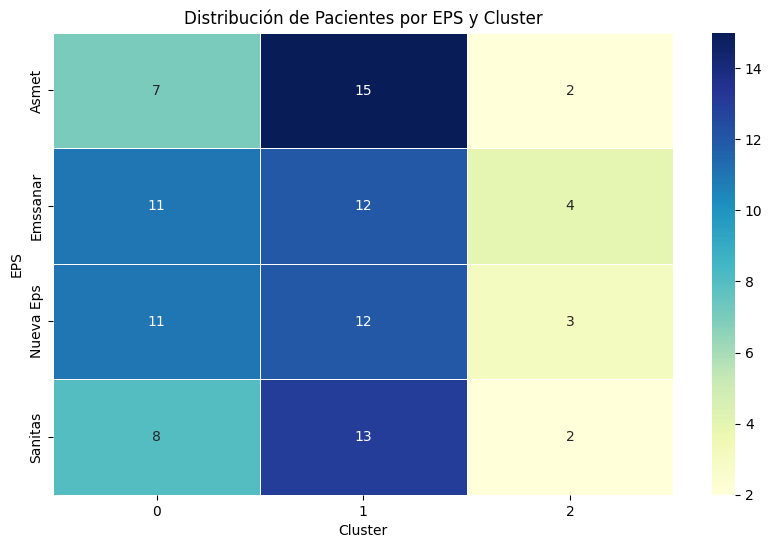

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Distribución de Pacientes por EPS y Cluster')
plt.xlabel('Cluster')
plt.ylabel('EPS')
plt.show()

### 10. Análisis de los Clusters (Variables Numéricas)

Para entender las características de cada cluster, calcularemos la media de todas las variables numéricas originales para cada grupo. Esto nos permitirá ver cómo difieren los clusters en términos de edad, admisiones, diagnósticos, etc.

Medias de las variables numéricas por Cluster:


,id_usuario,edad_referencia,total_admisiones,total_diagnosticos_icd,total_procedimientos_ Quirurgicos,total_estancias_uci,detalle_estancias_uci_es,ibm
cluster,,,,,,,,
0,1.001340e+07,53.297297,1.891892,28.837838,6.945946,1.162162,30.648649,23.351351
1,1.002204e+07,68.230769,1.980769,28.288462,4.000000,1.269231,21.480769,29.576923
2,1.002143e+07,59.545455,9.272727,178.909091,23.363636,2.818182,29.545455,26.363636


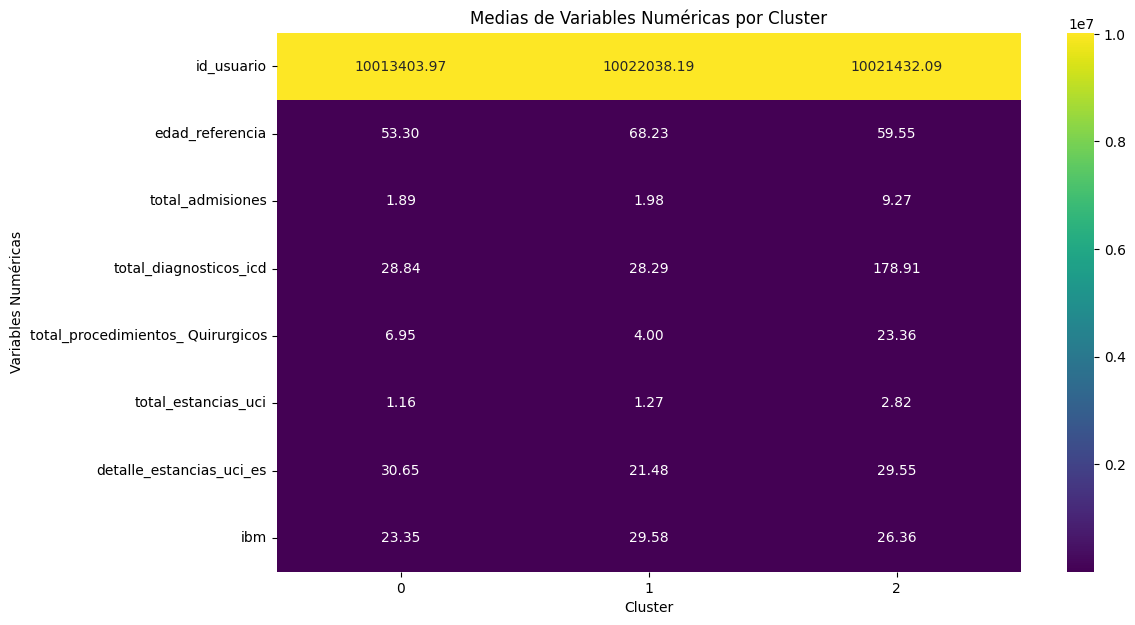

In [18]:
# Calcular las medias de las variables numéricas por cluster
cluster_means = df.groupby('cluster')[numerical_cols].mean()

print("Medias de las variables numéricas por Cluster:")
display(cluster_means)

# Opcional: Visualizar las medias si se desea (por ejemplo, con un heatmap o un barplot)
plt.figure(figsize=(12, 7))
sns.heatmap(cluster_means.T, annot=True, cmap='viridis', fmt=".2f")
plt.title('Medias de Variables Numéricas por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Variables Numéricas')
plt.show()

### 11. Análisis de los Clusters (Variables Categóricas)

Para complementar el análisis de las variables numéricas, ahora examinaremos la distribución de las variables categóricas ('sexo' y 'EPS') dentro de cada cluster. Esto nos ayudará a comprender si los clusters presentan patrones distintivos en cuanto a la composición de género o la entidad promotora de salud (EPS).


Distribución de 'sexo' por Cluster:


sexo,Femenino,Masculino
cluster,,
0,0.459459,0.540541
1,0.403846,0.596154
2,0.454545,0.545455


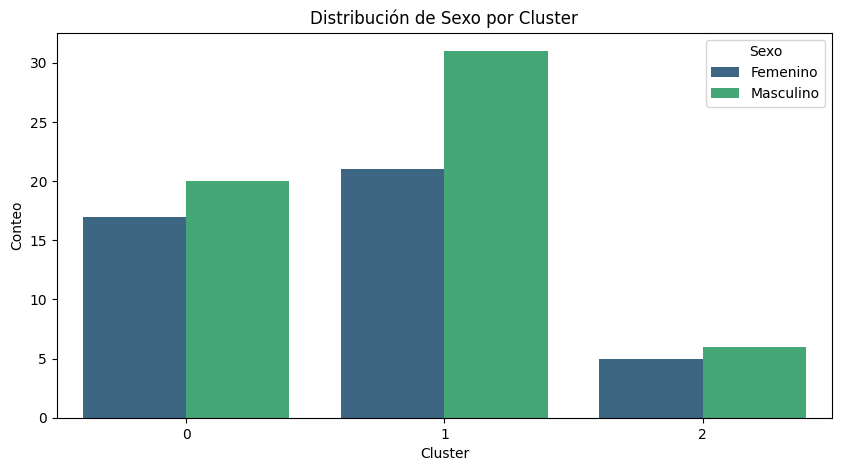


Distribución de 'EPS' por Cluster:


EPS,Asmet,Emssanar,Nueva Eps,Sanitas
cluster,,,,
0,0.189189,0.297297,0.297297,0.216216
1,0.288462,0.230769,0.230769,0.250000
2,0.181818,0.363636,0.272727,0.181818


/tmp/ipykernel_34028/3720884084.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eps_proportions = eps_counts.groupby('cluster').apply(lambda x: 100 * x['count'] / x['count'].sum()).reset_index(name='proportion')


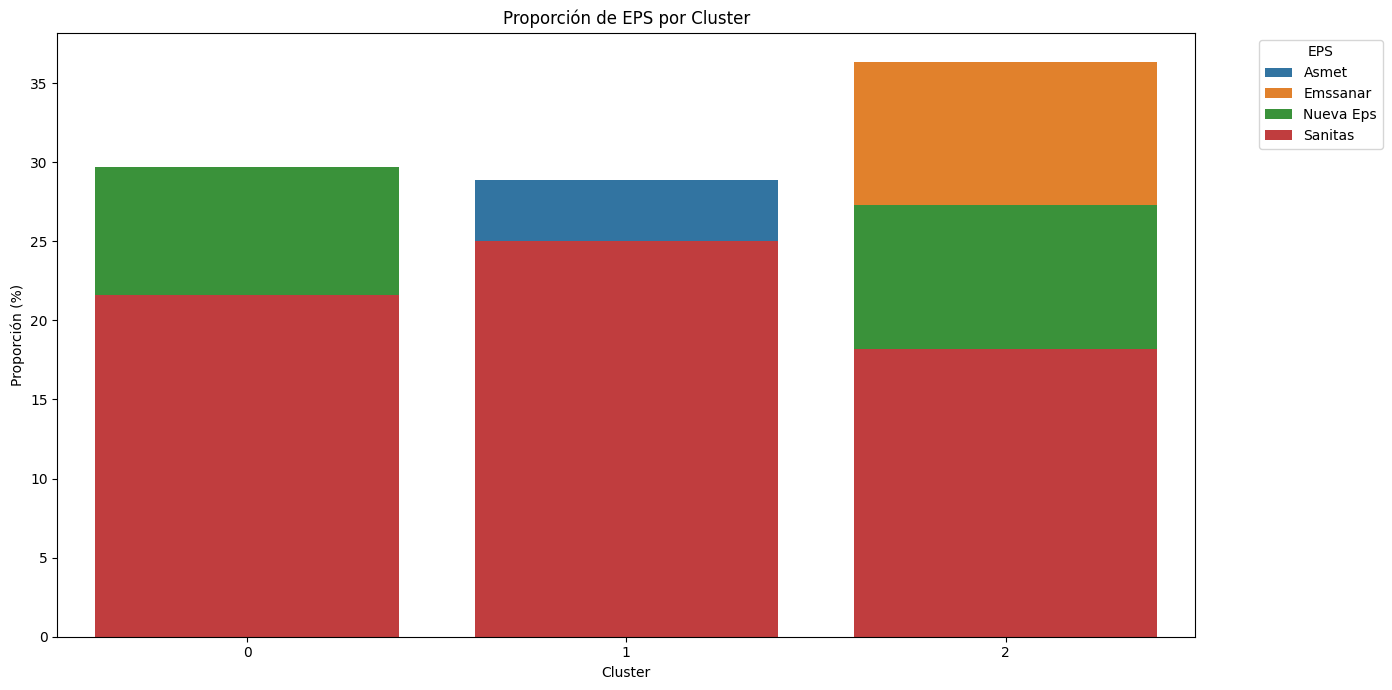

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis de 'sexo' por cluster
print("\nDistribución de 'sexo' por Cluster:")
display(df.groupby('cluster')['sexo'].value_counts(normalize=True).unstack(fill_value=0))

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='cluster', hue='sexo', palette='viridis')
plt.title('Distribución de Sexo por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Conteo')
plt.legend(title='Sexo')
plt.show()

# Análisis de 'EPS' por cluster
print("\nDistribución de 'EPS' por Cluster:")
display(df.groupby('cluster')['EPS'].value_counts(normalize=True).unstack(fill_value=0))

# Para EPS, debido a la cantidad de categorías, usaremos un barplot apilado o con facetas
# Usaremos un barplot para ver las proporciones dentro de cada cluster
eps_counts = df.groupby(['cluster', 'EPS']).size().reset_index(name='count')
eps_proportions = eps_counts.groupby('cluster').apply(lambda x: 100 * x['count'] / x['count'].sum()).reset_index(name='proportion')
eps_proportions['EPS'] = eps_counts['EPS'] # Add EPS back

plt.figure(figsize=(14, 7))
sns.barplot(data=eps_proportions, x='cluster', y='proportion', hue='EPS', palette='tab10', dodge=False)
plt.title('Proporción de EPS por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proporción (%)')
plt.legend(title='EPS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 12. Visualización de Clusters con PCA

Para visualizar los clusters en un espacio bidimensional, aplicaremos el Análisis de Componentes Principales (PCA) a nuestros datos numéricos escalados. PCA nos ayudará a reducir la dimensionalidad de los datos, proyectándolos en los dos componentes principales que capturan la mayor varianza. Luego, graficaremos estos componentes y colorearemos los puntos según el cluster al que pertenecen, lo que nos permitirá observar la separación visual de los grupos.

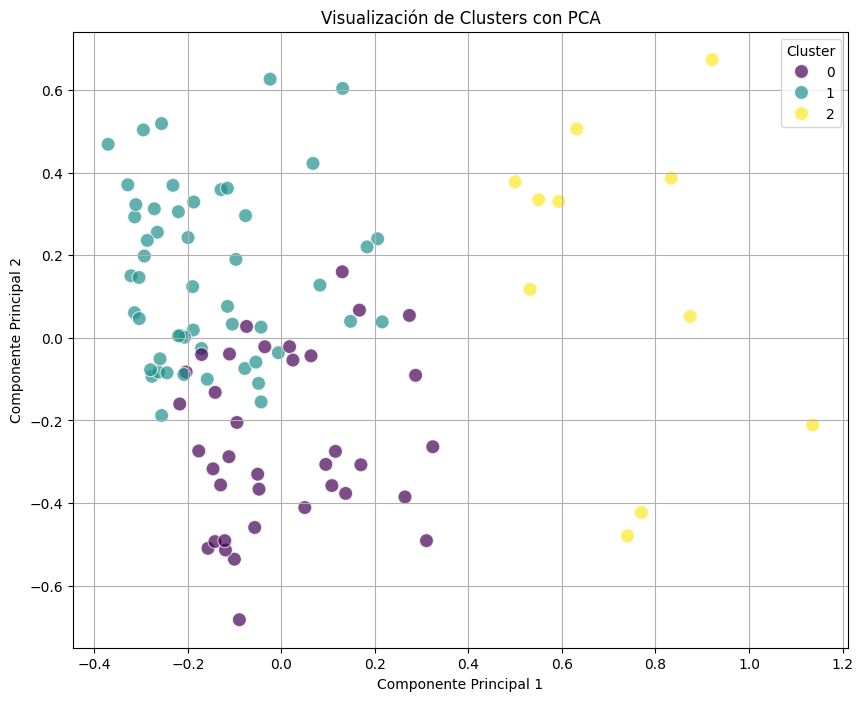

In [20]:
from sklearn.decomposition import PCA

# Aplicar PCA para reducir la dimensionalidad a 2 componentes
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_numerical_scaled.drop(columns=['cluster']))

# Crear un DataFrame para los componentes PCA y las etiquetas de cluster
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['cluster'] = clusters

# Visualizar los clusters usando un diagrama de dispersión
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('Visualización de Clusters con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

### 13. Resumen Detallado de los Clusters

A continuación, se presenta un perfil detallado de cada uno de los clusters identificados, combinando el análisis de sus características numéricas y categóricas:

#### **Cluster 0: El Paciente de Utilización Moderada**
*   **Características Numéricas:**
    *   **Edad Media:** 53.3 años (rango medio).
    *   **Admisiones:** 1.9 (moderado).
    *   **Diagnósticos ICD:** 28.8 (moderado).
    *   **Procedimientos Quirúrgicos:** 6.9 (moderado).
    *   **Estancias en UCI:** 1.16 (baja/moderada).
    *   **IBM:** 23.35 (rango medio).
*   **Características Categóricas:**
    *   **Sexo:** Composición similar a la población general (ligeramente más masculino).
    *   **EPS:** Distribución variada, con una presencia ligeramente mayor de `Emssanar` y `Nueva Eps` en comparación con `Asmet` y `Sanitas`.
*   **Perfil General:** Este cluster representa a pacientes con una utilización moderada de los servicios de salud en todas las categorías. Son un grupo diverso en cuanto a su aseguradora, y la distribución por sexo es muy similar a la general.

#### **Cluster 1: El Paciente Mayor con Bajo Perfil Quirúrgico**
*   **Características Numéricas:**
    *   **Edad Media:** 68.2 años (el grupo más envejecido).
    *   **Admisiones:** 1.98 (moderado, similar al Cluster 0).
    *   **Diagnósticos ICD:** 28.2 (similar al Cluster 0).
    *   **Procedimientos Quirúrgicos:** 4.0 (los más bajos).
    *   **Estancias en UCI:** 1.27 (baja, similar al Cluster 0).
    *   **IBM:** 29.58 (el más alto).
*   **Características Categóricas:**
    *   **Sexo:** Ligeramente más masculino, similar a la población general.
    *   **EPS:** La distribución entre las diferentes EPS es bastante equilibrada.
*   **Perfil General:** Este cluster agrupa a los pacientes de mayor edad. A pesar de su edad, presentan un número relativamente bajo de procedimientos quirúrgicos y estancias en UCI. Destaca su Índice de Masa Corporal (IBM) más alto. Podrían ser pacientes con condiciones crónicas manejadas de forma ambulatoria o con patologías que no requieren intervenciones quirúrgicas frecuentes.

#### **Cluster 2: El Paciente de Alta Complejidad y Utilización de Servicios**
*   **Características Numéricas:**
    *   **Edad Media:** 59.5 años (rango medio-alto).
    *   **Admisiones:** 9.27 (el más alto).
    *   **Diagnósticos ICD:** 178.9 (el más alto).
    *   **Procedimientos Quirúrgicos:** 23.36 (los más altos).
    *   **Estancias en UCI:** 2.82 (las más altas).
    *   **IBM:** 26.36 (rango medio-alto).
*   **Características Categóricas:**
    *   **Sexo:** Proporción similar a la población general.
    *   **EPS:** Destaca una prevalencia significativamente mayor de pacientes de `Emssanar` (36.4%), con las otras EPS teniendo menor representación.
*   **Perfil General:** Este cluster se diferencia claramente como el grupo de pacientes de mayor complejidad y mayor utilización de todos los servicios de salud (admisiones, diagnósticos, procedimientos y estancias en UCI). La alta concentración de pacientes de `Emssanar` en este cluster podría sugerir factores específicos relacionados con esta EPS o con el tipo de pacientes que atiende, que requieren una mayor intervención médica.

### 14. Gráficos de Barras Comparativos de Variables Numéricas por Cluster

Para una visualización más clara de las diferencias entre clusters en términos de las variables numéricas, crearemos gráficos de barras para cada una de ellas. Esto nos ayudará a identificar rápidamente qué variables contribuyen más a la distinción entre los grupos.

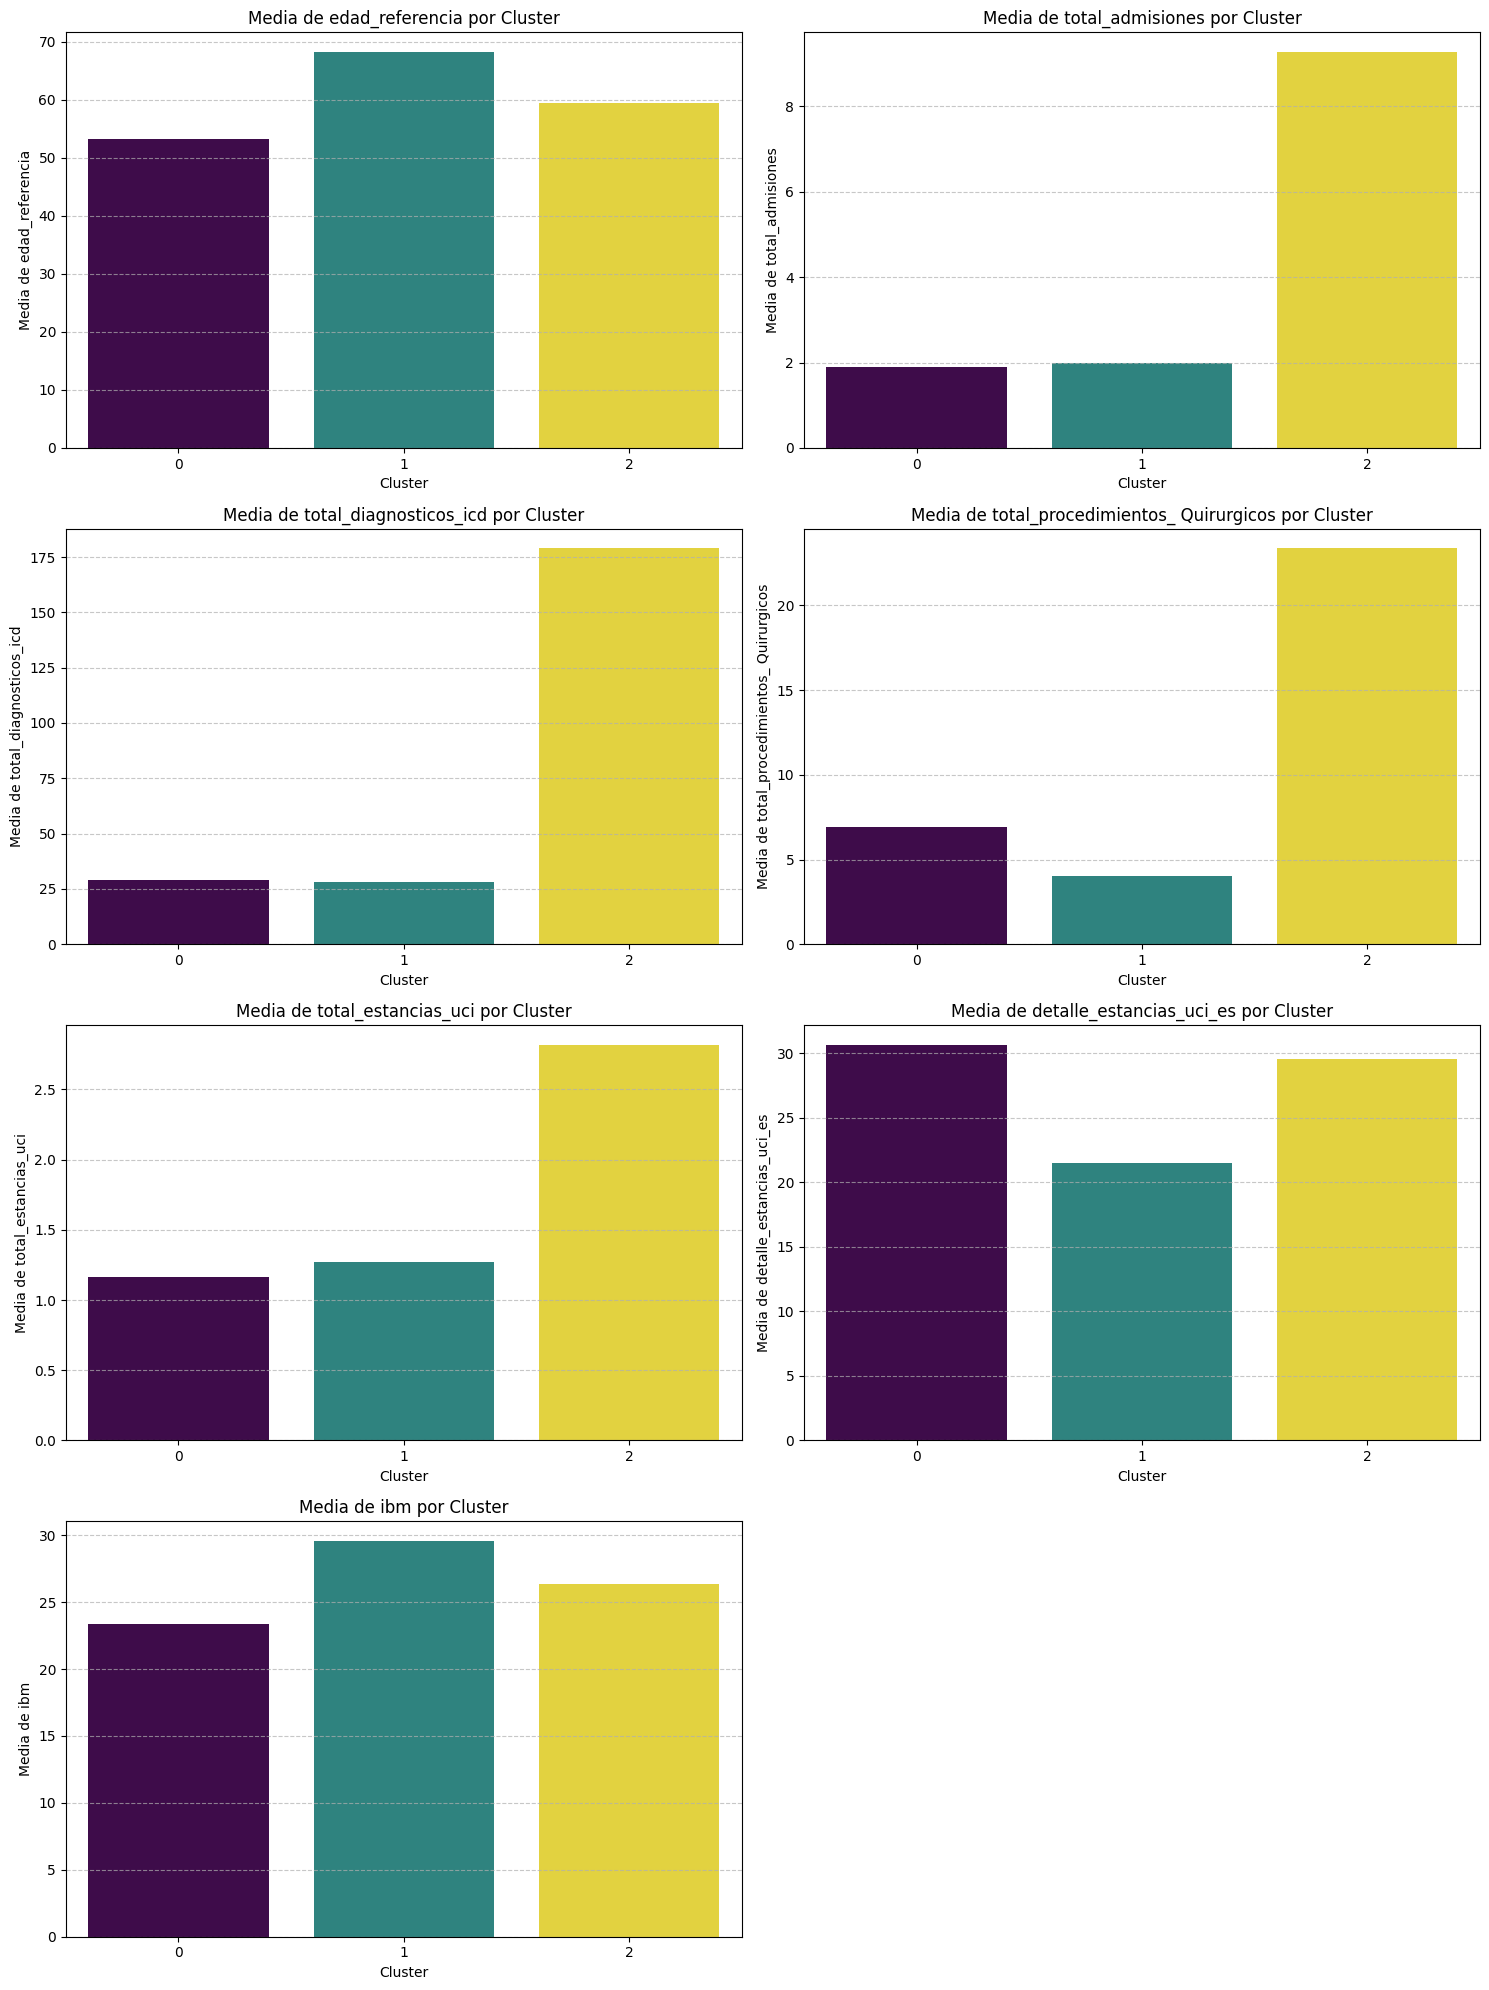

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas que se usaron en el clustering
numerical_cols_for_plot = [col for col in numerical_cols if col != 'id_usuario'] # Excluir 'id_usuario' si no es relevante para el análisis

# Número de filas y columnas para el subplots
n_cols = 2 # Por ejemplo, 2 columnas por fila
n_rows = (len(numerical_cols_for_plot) + n_cols - 1) // n_cols # Calcular el número de filas necesarias

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numerical_cols_for_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.barplot(x=cluster_means.index, y=col, data=cluster_means, palette='viridis', hue=cluster_means.index, legend=False)
    plt.title(f'Media de {col} por Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(f'Media de {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()